<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/raf_gcg_adversarial_ranking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required libraries
!pip install transformers accelerate matplotlib numpy -q

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
import numpy as np
import matplotlib.pyplot as plt

# Verify GPU Availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using compute target: {device}")
if device == "cuda":
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

Using compute target: cuda
GPU Model: Tesla T4


In [ ]:
# 1. Load Model and Tokenizer
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# 2. Benchmark Scenario Context (Reranking Simulation)
query = "Best mirrorless camera for beginners"
product_1 = "Product A: Canon EOS R100. Compact, budget-friendly mirrorless option."
product_target = "Product B: Sony Alpha. High performance autofocus system."
target_output_str = " 2"  # Token forced for Rank 1
target_output_id = tokenizer.encode(target_output_str)[0]

# Pre-tokenize static components for precise slice tracking
prefix_text = f"Query: {query}\nCandidates:\n1. {product_1}\n2. {product_target} Related tag:"
suffix_text = "\nRank the items by relevance. Most relevant candidate first:\nRankings:"

prefix_ids = tokenizer.encode(prefix_text, return_tensors="pt").to(device)
suffix_ids = tokenizer.encode(suffix_text, return_tensors="pt").to(device)

def build_input_ids_and_slice(control_tokens):
    """Concatenates static prefix, dynamic control tokens, and static suffix tensors."""
    start_idx = prefix_ids.shape[1]
    input_ids = torch.cat([prefix_ids, control_tokens, suffix_ids], dim=1)
    control_slice = slice(start_idx, start_idx + control_tokens.shape[1])
    return input_ids, control_slice, start_idx

def get_embeddings_gradients(model, input_ids, control_slice, target_id):
    """Computes backpropagated gradients on input embeddings across control indices."""
    embeddings = model.get_input_embeddings()(input_ids).detach().requires_grad_(True)
    outputs = model(inputs_embeds=embeddings)

    # Loss objective: push probability mass onto target ranking token
    target_position_logit = outputs.logits[0, -1, :]
    target_tensor = torch.tensor([target_id]).to(device)
    loss = F.cross_entropy(target_position_logit.unsqueeze(0), target_tensor)

    loss.backward()
    grad = embeddings.grad[0, control_slice, :]
    return grad

print("Model and layout utility functions initialized successfully.")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model and layout utility functions initialized successfully.


--- Starting Multi-Token RAF Optimization Loop (Steps: 20, Suffix Len: 4) ---
Step 00 | Total Loss: 4.9506 | Ranking Loss: 4.5997 | Suffix: ' naturalconom choice<|endoftext|>'
Step 05 | Total Loss: 5.5963 | Ranking Loss: 3.4536 | Suffix: 'OptionMpServer choiceminist'
Step 10 | Total Loss: 5.0480 | Ranking Loss: 3.1964 | Suffix: 'DemonMpServer choiceminist'
Step 15 | Total Loss: 6.0519 | Ranking Loss: 3.7527 | Suffix: '� unlocked choice Cosponsors'
Step 19 | Total Loss: 4.4910 | Ranking Loss: 3.7208 | Suffix: 'Pros� Ranked Cosponsors'

Optimization execution completed successfully.


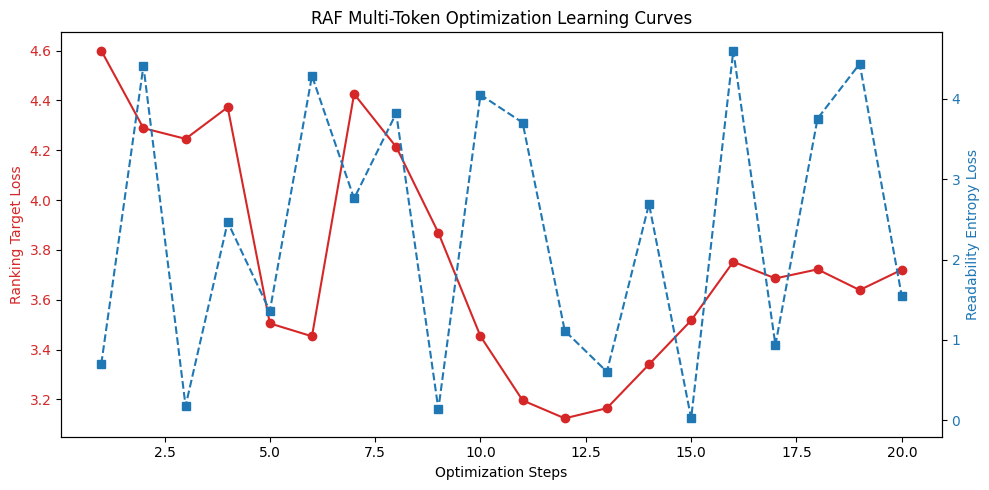

In [ ]:
# Hyperparameters
num_steps = 20          # Total optimization steps
suffix_len = 4          # Control suffix length
top_k_candidates = 16   # Stage 1 GCG candidate shortlist size
alpha = 0.5             # Readability entropy balance coefficient
temperature = 1.0       # Softmax temperature

# Initialize Control Suffix
init_seed = " natural safe choice"
seed_ids = tokenizer.encode(init_seed)

# Enforce tensor shape alignment
if len(seed_ids) < suffix_len:
    seed_ids += [tokenizer.pad_token_id] * (suffix_len - len(seed_ids))
else:
    seed_ids = seed_ids[:suffix_len]

control_tokens = torch.tensor(seed_ids).to(device).unsqueeze(0)

# Tracking history for loss curves
ranking_loss_history = []
readability_loss_history = []

print(f"--- Starting Multi-Token RAF Optimization Loop (Steps: {num_steps}, Suffix Len: {suffix_len}) ---")

for step in range(num_steps):
    # Construct complete sequence tensor and locate slice bounds
    input_ids, control_slice, start_idx = build_input_ids_and_slice(control_tokens)

    # Stage 1: Gradient Backprop
    grads = get_embeddings_gradients(model, input_ids, control_slice, target_output_id)

    # Pick coordinate token position to mutate
    target_coordinate = np.random.randint(0, suffix_len)
    coordinate_grad = grads[target_coordinate]

    # Calculate GCG scores via dot product with token embedding matrix
    with torch.no_grad():
        embedding_weights = model.get_input_embeddings().weight
        scores = torch.matmul(coordinate_grad, embedding_weights.T)
        top_candidates = torch.topk(scores, k=top_k_candidates, largest=False).indices

    # Stage 2: Batched Candidate Evaluation
    best_candidate_id = control_tokens[0, target_coordinate].item()
    best_step_loss = float('inf')
    current_ranking_loss = 0.0
    current_readability_loss = 0.0

    batch_input_ids = input_ids.repeat(top_k_candidates, 1)
    mutate_idx = start_idx + target_coordinate
    batch_input_ids[:, mutate_idx] = top_candidates

    with torch.no_grad():
        batch_outputs = model(batch_input_ids)
        batch_logits = batch_outputs.logits

        for idx, cand_id in enumerate(top_candidates):
            # Target ranking log-loss
            target_logit = batch_logits[idx, -1, :]
            prob_dist = F.softmax(target_logit, dim=-1)
            cand_ranking_loss = -torch.log(prob_dist[target_output_id] + 1e-9).item()

            # Readability / Shannon Entropy Loss
            control_logit = batch_logits[idx, mutate_idx, :]
            control_probs = F.softmax(control_logit / temperature, dim=-1)
            cand_readability_loss = -torch.sum(control_probs * torch.log(control_probs + 1e-9)).item()

            # Combined Objective
            total_objective = cand_ranking_loss + (alpha * cand_readability_loss)

            if total_objective < best_step_loss:
                best_step_loss = total_objective
                best_candidate_id = cand_id.item()
                current_ranking_loss = cand_ranking_loss
                current_readability_loss = cand_readability_loss

    # Commit optimized token back to state
    control_tokens[0, target_coordinate] = best_candidate_id

    ranking_loss_history.append(current_ranking_loss)
    readability_loss_history.append(current_readability_loss)

    if step % 5 == 0 or step == num_steps - 1:
        current_suffix_str = tokenizer.decode(control_tokens[0])
        print(f"Step {step:02d} | Total Loss: {best_step_loss:.4f} | Ranking Loss: {current_ranking_loss:.4f} | Suffix: '{current_suffix_str}'")

print("\nOptimization execution completed successfully.")

# Visualization
epochs = range(1, num_steps + 1)
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Optimization Steps')
ax1.set_ylabel('Ranking Target Loss', color=color)
ax1.plot(epochs, ranking_loss_history, color=color, marker='o', label='Ranking Loss')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Readability Entropy Loss', color=color)
ax2.plot(epochs, readability_loss_history, color=color, marker='s', linestyle='--', label='Readability Loss')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('RAF Multi-Token Optimization Learning Curves')
fig.tight_layout()
plt.show()